# NC Education and Income Data - Block Groups to Precincts

## Package Imports

In [1]:
# maup
import maup
maup.progress.enabled = True

# dataframes
import pandas as pd
import geopandas as gpd
from pathlib import Path
BASE_DIR = Path().resolve().parent.parent
NOT_GIT_DIR = Path().resolve().parent.parent.parent


## Import Data

In [2]:
# Education Level CSV files
education_2022 = pd.read_csv(BASE_DIR / "NC-Education" / "2022education-Data.csv")
education_2023 = pd.read_csv(BASE_DIR / "NC-Education" / "2023education-Data.csv")

# Income Level CSV files
income_2022 = pd.read_csv(BASE_DIR / "NC-Income/2022income-Data.csv")
income_2023 = pd.read_csv(BASE_DIR / "NC-Income/2023income-Data.csv")

# Block Groups Shapefile
block_groups_2022 = gpd.read_file(NOT_GIT_DIR / "tl_2022_37_bg/tl_2022_37_bg.shp")
block_groups_2023 = gpd.read_file(NOT_GIT_DIR / "tl_2023_37_bg/tl_2023_37_bg.shp")

# Precincts Voting Data and Shapefile (This is updated!)
time_period_11822_72822_gdf = gpd.read_file(BASE_DIR / "Shapefile_Data" / "SBE_PRECINCTS_20220118" / "SBE_PRECINCTS_20220118.shp")
time_period_72922_83022_gdf = gpd.read_file(BASE_DIR / "Shapefile_Data" / "SBE_PRECINCTS_20220729" / "SBE_PRECINCTS_20220729.shp")
time_period_83122_123122_gdf = gpd.read_file(BASE_DIR / "Shapefile_Data" / "SBE_PRECINCTS_20220831" / "SBE_PRECINCTS_20220831.shp")
time_period_1123_121923_gdf = gpd.read_file(BASE_DIR / "Shapefile_Data" / "SBE_PRECINCTS_20220831" / "SBE_PRECINCTS_20220831.shp")


## Clean up the Data and Naming

In [3]:
# The columns for the Education Data are really weirdly named. Let's clean that up.
education_2022["total_vap"] = education_2022["B29002_001E"]
education_2022["under_9g"] = education_2022["B29002_002E"]
education_2022["9_to_12_nd"] = education_2022["B29002_003E"]
education_2022["hs_grad"] = education_2022["B29002_004E"]
education_2022["scol_nd"] = education_2022["B29002_005E"]
education_2022["assoc_deg"] = education_2022["B29002_006E"]
education_2022["bach_deg"] = education_2022["B29002_007E"]
education_2022["grad_deg_p"] = education_2022["B29002_008E"]
education_2022["GEOID"] = education_2022["GEO_ID"]

# Now, only keep the columns we want.
filtered_columns = ["GEOID", "total_vap", "under_9g", "9_to_12_nd", "hs_grad", "scol_nd", "assoc_deg", "bach_deg", "grad_deg_p"]
education_2022 = education_2022[filtered_columns]

# The first column is just some weird extra titles, so we can drop that
education_2022 = education_2022.drop(index=education_2022.index[0]) 

In [4]:
# Now, we'll do the exact same thing for 2023. 2023 will have the same columns, so we can repeat the same code.
# The columns for the Education Data are really weirdly named. Let's clean that up.
education_2023["total_vap"] = education_2023["B29002_001E"]
education_2023["under_9g"] = education_2023["B29002_002E"]
education_2023["9_to_12_nd"] = education_2023["B29002_003E"]
education_2023["hs_grad"] = education_2023["B29002_004E"]
education_2023["scol_nd"] = education_2023["B29002_005E"]
education_2023["assoc_deg"] = education_2023["B29002_006E"]
education_2023["bach_deg"] = education_2023["B29002_007E"]
education_2023["grad_deg_p"] = education_2023["B29002_008E"]
education_2023["GEOID"] = education_2023["GEO_ID"]

# Now, only keep the columns we want.
filtered_columns = ["GEOID", "total_vap", "under_9g", "9_to_12_nd", "hs_grad", "scol_nd", "assoc_deg", "bach_deg", "grad_deg_p"]
education_2023 = education_2023[filtered_columns]

# The first column is just some weird extra titles, so we can drop that
education_2023 = education_2023.drop(index=education_2023.index[0]) 

In [5]:
# The columns for the Income Data are really weirdly named. Let's clean that up.
income_2022["less_10k"] = income_2022["B19001_002E"]
income_2022["10k_15k"] = income_2022["B19001_003E"]
income_2022["15k_20k"] = income_2022["B19001_004E"]
income_2022["20k_25k"] = income_2022["B19001_005E"]
income_2022["25k_30k"] = income_2022["B19001_006E"]
income_2022["30k_35k"] = income_2022["B19001_007E"]
income_2022["35k_40k"] = income_2022["B19001_008E"]
income_2022["40k_45k"] = income_2022["B19001_009E"]
income_2022["45k_50k"] = income_2022["B19001_010E"]
income_2022["50k_60k"] = income_2022["B19001_011E"]
income_2022["60k_75k"] = income_2022["B19001_012E"]
income_2022["75k_100k"] = income_2022["B19001_013E"]
income_2022["100k_125k"] = income_2022["B19001_014E"]
income_2022["125k_150k"] = income_2022["B19001_015E"]
income_2022["150k_200k"] = income_2022["B19001_016E"]
income_2022["200k_plus"] = income_2022["B19001_017E"]
income_2022["GEOID"] = income_2022["GEO_ID"]

# Now, only keep the columns we want.
filtered_columns = ["GEOID", "less_10k", "10k_15k", "15k_20k", "20k_25k", "25k_30k", "30k_35k", "35k_40k",
                    "40k_45k", "45k_50k", "50k_60k", "60k_75k", "75k_100k", "100k_125k", "125k_150k", "150k_200k", "200k_plus"]
income_2022 = income_2022[filtered_columns]

# The first column is just some weird extra titles, so we can drop that
income_2022 = income_2022.drop(index=income_2022.index[0]) 

In [6]:
# The columns for the Income Data are really weirdly named. Let's clean that up.
income_2023["less_10k"] = income_2023["B19001_002E"]
income_2023["10k_15k"] = income_2023["B19001_003E"]
income_2023["15k_20k"] = income_2023["B19001_004E"]
income_2023["20k_25k"] = income_2023["B19001_005E"]
income_2023["25k_30k"] = income_2023["B19001_006E"]
income_2023["30k_35k"] = income_2023["B19001_007E"]
income_2023["35k_40k"] = income_2023["B19001_008E"]
income_2023["40k_45k"] = income_2023["B19001_009E"]
income_2023["45k_50k"] = income_2023["B19001_010E"]
income_2023["50k_60k"] = income_2023["B19001_011E"]
income_2023["60k_75k"] = income_2023["B19001_012E"]
income_2023["75k_100k"] = income_2023["B19001_013E"]
income_2023["100k_125k"] = income_2023["B19001_014E"]
income_2023["125k_150k"] = income_2023["B19001_015E"]
income_2023["150k_200k"] = income_2023["B19001_016E"]
income_2023["200k_plus"] = income_2023["B19001_017E"]
income_2023["GEOID"] = income_2023["GEO_ID"]

# Now, only keep the columns we want.
filtered_columns = ["GEOID", "less_10k", "10k_15k", "15k_20k", "20k_25k", "25k_30k", "30k_35k", "35k_40k",
                    "40k_45k", "45k_50k", "50k_60k", "60k_75k", "75k_100k", "100k_125k", "125k_150k", "150k_200k", "200k_plus"]
income_2023 = income_2023[filtered_columns]

# The first column is just some weird extra titles, so we can drop that
income_2023 = income_2023.drop(index=income_2023.index[0]) 

## Merge!

In [7]:
# To merge the education data with our block shapefile, we need to have a common column to merge on.
# Luckily, GEOID should work (with a little bit of ~magic~)

# Our education dataframes have a longer GEOID, so we can cut the first part and it should match up with the Block Groups shapefile.
education_2022["GEOID"] = education_2022["GEOID"].str[9:]
education_2023["GEOID"] = education_2023["GEOID"].str[9:]

# Do the saem for GEOID
income_2022["GEOID"] = income_2022["GEOID"].str[9:]
income_2023["GEOID"] = income_2023["GEOID"].str[9:]

In [8]:
# Confirm that we have a matching column to join on! 
# This is just a test of one specific GEOID, but if it works most likely everything else worked
if ((education_2022["GEOID"] == "370010201002").any()):
    print("Found")
if ((block_groups_2022["GEOID"] == "370010201002").any()):
    print("Found")
else:
    print("Not found")


# Just confirm also works for income_2022
if ((income_2022["GEOID"] == "370010201002").any()):
    print("Found")
if ((block_groups_2022["GEOID"] == "370010201002").any()):
    print("Found")
else:
    print("Not found")

Found
Found
Found
Found


In [9]:
# We have to do two merges - merge income and education, then both with block_groups shapefile

# Education and Income
merged_education_income_2022_df = income_2022.merge(education_2022, on = ["GEOID"], how = "left")
merged_education_income_2023_df = income_2023.merge(education_2023, on = ["GEOID"], how = "left")

# Combined with Shapefile
nc_data_2022_gdf = block_groups_2022.merge(merged_education_income_2022_df, on = ["GEOID"], how = "left")
nc_data_2023_gdf = block_groups_2023.merge(merged_education_income_2023_df, on = ["GEOID"], how = "left")



## Aggregate up to Precinct Level using Maup Package

### Start with between 1/18/2022 and 7/28/2022

In [10]:
# We need both shapefiles to be in the same CRS
nc_data_2022_gdf = nc_data_2022_gdf.to_crs(epsg = 26915)
time_period_11822_72822_gdf = time_period_11822_72822_gdf.to_crs(epsg = 26915)

In [11]:
# The columns with numbers need to be summed so that we can properly aggregate up to Precinct level
pop_cols = ["total_vap", "under_9g", "9_to_12_nd", "hs_grad", "scol_nd", "assoc_deg", "bach_deg", "grad_deg_p", "less_10k", "10k_15k", "15k_20k", "20k_25k", "25k_30k", "30k_35k", "35k_40k",
                    "40k_45k", "45k_50k", "50k_60k", "60k_75k", "75k_100k", "100k_125k", "125k_150k", "150k_200k", "200k_plus"]

# Using maup.assign, it will figure out how to move from block groups to precincts using the Shapefiles
blocks_to_precincts_assignment = maup.assign(nc_data_2022_gdf.geometry, time_period_11822_72822_gdf.geometry)

# We need to get all the data types of P1 to ints
for item in pop_cols:
    nc_data_2022_gdf[item] = pd.to_numeric(nc_data_2022_gdf[item])

time_period_11822_72822_gdf[pop_cols] = nc_data_2022_gdf[pop_cols].groupby(blocks_to_precincts_assignment).sum()

100%|██████████| 2663/2663 [00:03<00:00, 771.51it/s]


In [12]:
time_period_11822_72822_gdf.to_file(BASE_DIR / "EducationIncome_MergedShapefiles" / "time_period_11822_72822.shp")

### Now, between 7/29/2022 and 8/30/2022

In [13]:
# We need both shapefiles to be in the same CRS
nc_data_2022_gdf = nc_data_2022_gdf.to_crs(epsg = 26915)
time_period_72922_83022_gdf = time_period_72922_83022_gdf.to_crs(epsg = 26915)

In [14]:
# The columns with numbers need to be summed so that we can properly aggregate up to Precinct level
pop_cols = ["total_vap", "under_9g", "9_to_12_nd", "hs_grad", "scol_nd", "assoc_deg", "bach_deg", "grad_deg_p", "less_10k", "10k_15k", "15k_20k", "20k_25k", "25k_30k", "30k_35k", "35k_40k",
                    "40k_45k", "45k_50k", "50k_60k", "60k_75k", "75k_100k", "100k_125k", "125k_150k", "150k_200k", "200k_plus"]

# Using maup.assign, it will figure out how to move from block groups to precincts using the Shapefiles
blocks_to_precincts_assignment = maup.assign(nc_data_2022_gdf.geometry, time_period_72922_83022_gdf.geometry)

# We need to get all the data types of P1 to ints
for item in pop_cols:
    nc_data_2022_gdf[item] = pd.to_numeric(nc_data_2022_gdf[item])

time_period_72922_83022_gdf[pop_cols] = nc_data_2022_gdf[pop_cols].groupby(blocks_to_precincts_assignment).sum()

100%|██████████| 2659/2659 [00:03<00:00, 773.14it/s]


In [15]:
time_period_72922_83022_gdf.to_file(BASE_DIR / "EducationIncome_MergedShapefiles" / "time_period_72922_83022.shp")

### Now, 8/30/2022 to 12/31/2022
Technically, the precinct shapefile is valid all the way up to 12/19/23, but I want to seperate it into 2022 data and 2023 data

In [16]:
# We need both shapefiles to be in the same CRS
nc_data_2022_gdf = nc_data_2022_gdf.to_crs(epsg = 26915)
time_period_83122_123122_gdf = time_period_83122_123122_gdf.to_crs(epsg = 26915)

In [17]:
# The columns with numbers need to be summed so that we can properly aggregate up to Precinct level
pop_cols = ["total_vap", "under_9g", "9_to_12_nd", "hs_grad", "scol_nd", "assoc_deg", "bach_deg", "grad_deg_p", "less_10k", "10k_15k", "15k_20k", "20k_25k", "25k_30k", "30k_35k", "35k_40k",
                    "40k_45k", "45k_50k", "50k_60k", "60k_75k", "75k_100k", "100k_125k", "125k_150k", "150k_200k", "200k_plus"]

# Using maup.assign, it will figure out how to move from block groups to precincts using the Shapefiles
blocks_to_precincts_assignment = maup.assign(nc_data_2022_gdf.geometry, time_period_83122_123122_gdf.geometry)

# We need to get all the data types of P1 to ints
for item in pop_cols:
    nc_data_2022_gdf[item] = pd.to_numeric(nc_data_2022_gdf[item])

time_period_83122_123122_gdf[pop_cols] = nc_data_2022_gdf[pop_cols].groupby(blocks_to_precincts_assignment).sum()

100%|██████████| 2652/2652 [00:03<00:00, 775.77it/s]


In [18]:
time_period_83122_123122_gdf.to_file(BASE_DIR / "EducationIncome_MergedShapefiles" / "time_period_83122_123122.shp")

### Finally 1/1/2023 and 12/19/2023

In [19]:
# We need both shapefiles to be in the same CRS
nc_data_2023_gdf = nc_data_2023_gdf.to_crs(epsg = 26915)
time_period_1123_121923_gdf = time_period_1123_121923_gdf.to_crs(epsg = 26915)

In [20]:
# The columns with numbers need to be summed so that we can properly aggregate up to Precinct level
pop_cols = ["total_vap", "under_9g", "9_to_12_nd", "hs_grad", "scol_nd", "assoc_deg", "bach_deg", "grad_deg_p", "less_10k", "10k_15k", "15k_20k", "20k_25k", "25k_30k", "30k_35k", "35k_40k",
                    "40k_45k", "45k_50k", "50k_60k", "60k_75k", "75k_100k", "100k_125k", "125k_150k", "150k_200k", "200k_plus"]

# Using maup.assign, it will figure out how to move from block groups to precincts using the Shapefiles
blocks_to_precincts_assignment = maup.assign(nc_data_2023_gdf.geometry, time_period_1123_121923_gdf.geometry)

# We need to get all the data types of P1 to ints
for item in pop_cols:
    nc_data_2023_gdf[item] = pd.to_numeric(nc_data_2023_gdf[item])

time_period_1123_121923_gdf[pop_cols] = nc_data_2023_gdf[pop_cols].groupby(blocks_to_precincts_assignment).sum()

100%|██████████| 2652/2652 [00:03<00:00, 780.45it/s]


In [21]:
time_period_1123_121923_gdf.to_file(BASE_DIR / "EducationIncome_MergedShapefiles" / "time_period_1123_121923.shp")

## Check that it worked

<Axes: >

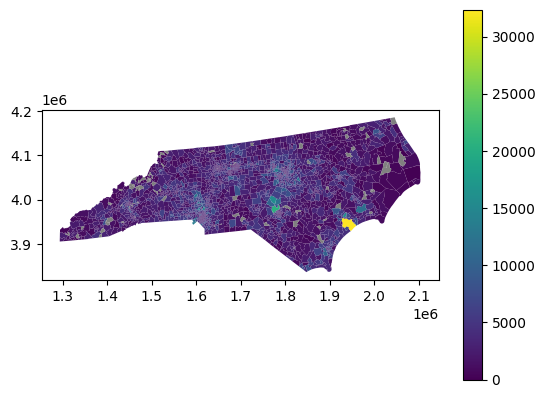

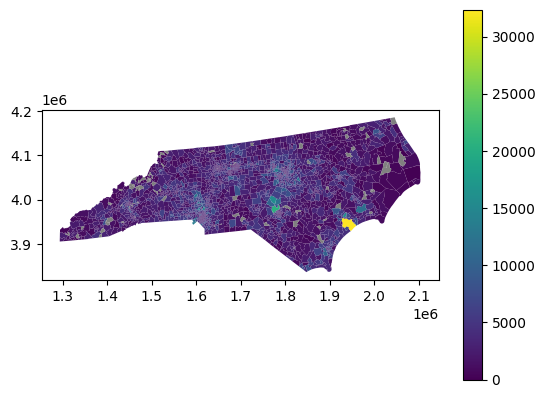

In [22]:
# Let's make a plot to see if it looks good!
time_period_1123_121923_gdf.plot(column = 'total_vap', missing_kwds = {"color":"grey"}, legend=True)
time_period_1123_121923_gdf.plot(column = 'total_vap', missing_kwds = {"color":"grey"}, legend=True)


<Axes: >

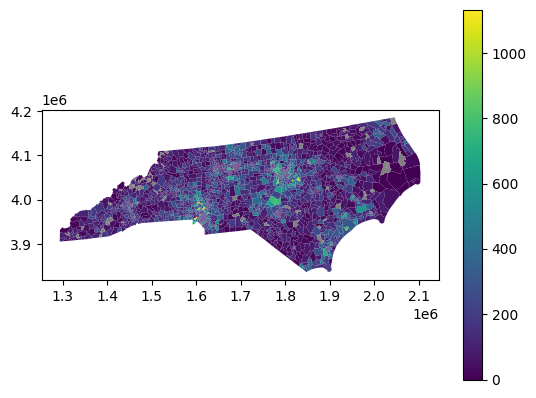

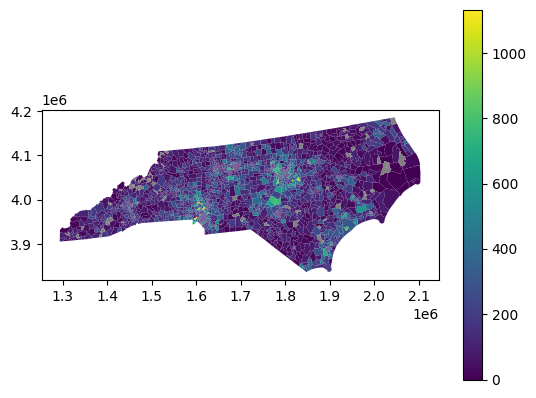

In [23]:
# Let's make a plot to see if it looks good!
time_period_1123_121923_gdf.plot(column = '100k_125k', missing_kwds = {"color":"grey"}, legend=True)
time_period_1123_121923_gdf.plot(column = '100k_125k', missing_kwds = {"color":"grey"}, legend=True)